In [1]:
# 📧 Email Spam Classification using Machine Learning

#This project classifies emails into Spam or Ham using TF-IDF and Logistic Regression.

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import warnings 

In [6]:
warnings.filterwarnings("ignore") # filter any future erors in model

In [7]:
from sklearn.model_selection import train_test_split # library that train model on data set (80%) and test data(20%)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer  

In [9]:
from sklearn.metrics import accuracy_score  #calculate accuracy score of the model

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

In [11]:
raw_mail=pd.read_csv("mail_data.csv") # Read the data set file

In [12]:
raw_mail.head() # print the first 5 rows in the data set

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df=raw_mail.where((pd.notnull(raw_mail)),'') # replace any null space by a blank space 

In [14]:
df.isnull().sum()  # calculate  the sum of null space after replacing 

Category    0
Message     0
dtype: int64

In [15]:
df.shape  # shape of fata det 5572 is number of rows and 2 is the columns

(5572, 2)

In [16]:
df['Category']=df['Category'].map({'ham':1 , 'spam':0}) # replace ham by 1 and spam by 0

In [17]:
df.head()

,Category,Message
0,1,"Go until jurong point, crazy.. Available only ..."
1,1,Ok lar... Joking wif u oni...
2,0,Free entry in 2 a wkly comp to win FA Cup fina...
3,1,U dun say so early hor... U c already then say...
4,1,"Nah I don't think he goes to usf, he lives aro..."


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   int64 
 1   Message   5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


In [18]:
x= df['Message']
y= df['Category']

In [19]:
x

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: object

In [20]:
y

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: int64

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3,random_state=45)

In [22]:
x_train.shape

(3900,)

In [23]:
y_train.shape

(3900,)

In [24]:
x_test.shape

(1672,)

In [25]:
feature_extraction =TfidfVectorizer(min_df=1 ,stop_words='english',binary=True)

In [26]:
x_train_features=feature_extraction.fit_transform(x_train)

In [27]:
x_test_features=feature_extraction.transform(x_test)

In [29]:
y_train=y_train.astype("int")

In [30]:
y_test=y_test.astype("int")

In [31]:
x_train

1201             Otherwise had part time job na-tuition..
77      I like you peoples very much:) but am very shy...
1346      Que pases un buen tiempo or something like that
2753                            Sat right? Okay thanks...
3097    We walked from my moms. Right on stagwood pass...
                              ...                        
4473      3. You have received your mobile content. Enjoy
580     Arngd marriage is while u r walkin unfortuntly...
163     I'm so in love with you. I'm excited each day ...
4703                                           Anytime...
3616    I enjoy watching and playing football and bask...
Name: Message, Length: 3900, dtype: object

In [32]:
print(x_train_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30496 stored elements and shape (3900, 6956)>
  Coords	Values
  (0, 6211)	0.32834254096893517
  (0, 3438)	0.4460567775394737
  (0, 4211)	0.5887378563508396
  (0, 6364)	0.5887378563508396
  (1, 3696)	0.2995089121224971
  (1, 4615)	0.6205569656023386
  (1, 5533)	0.5704000993973541
  (1, 4524)	0.447042716761055
  (2, 3696)	0.234588492871981
  (2, 4958)	0.4860473842672267
  (2, 4571)	0.4860473842672267
  (2, 1375)	0.4860473842672267
  (2, 6203)	0.4860473842672267
  (3, 5330)	0.5405472959281137
  (3, 5205)	0.4489892326662737
  (3, 4423)	0.536796499968435
  (3, 6134)	0.46697623862054605
  (4, 5205)	0.20958449230864243
  (4, 6622)	0.33611741324541244
  (4, 4112)	0.3076023437326441
  (4, 5797)	0.35279765961583903
  (4, 4572)	0.2790872742198758
  (4, 6765)	0.35279765961583903
  (4, 3659)	0.2541517265357278
  (4, 6546)	0.35279765961583903
  :	:
  (3896, 3798)	0.15541481152994124
  (3896, 5641)	0.29099010600131214
  (3896, 847)	0.19008

In [33]:
print(x_test_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11387 stored elements and shape (1672, 6956)>
  Coords	Values
  (0, 1636)	0.32377115085821645
  (0, 2185)	0.3791588586928237
  (0, 2932)	0.1843270474765624
  (0, 3122)	0.348513130419624
  (0, 3561)	0.18273840566723917
  (0, 3696)	0.18299924677900875
  (0, 3818)	0.18459746079784595
  (0, 4155)	0.3080016812269975
  (0, 4257)	0.20619877548797175
  (0, 4989)	0.3612322568457117
  (0, 5408)	0.33058652857251214
  (0, 5683)	0.2351104603261168
  (0, 6897)	0.2501570946710533
  (1, 2251)	0.39410310629075
  (1, 2261)	0.35630895855338135
  (1, 2932)	0.24219399932061295
  (1, 3481)	0.21816920055188083
  (1, 3818)	0.24254930520028622
  (1, 3894)	0.3851481340926751
  (1, 4591)	0.35630895855338135
  (1, 5344)	0.29777277326405077
  (1, 6933)	0.4343696412034993
  (2, 2157)	0.5654241293008087
  (2, 4697)	0.8248003115933106
  (3, 242)	0.6602052668811638
  :	:
  (1670, 2867)	0.1827834786610419
  (1670, 3890)	0.2191130441852178
  (1670, 4129)	0.34

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
model=LogisticRegression()
model.fit(x_train_features,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
prediction_train_data=model.predict(x_train_features)

In [37]:
acc_train_data=accuracy_score(y_train,prediction_train_data)

In [38]:
print("accuracy train data is",acc_train_data)

accuracy train data is 0.9653846153846154


In [39]:
prediction_test_data=model.predict(x_test_features)

In [40]:
acc_test_data=accuracy_score(y_test,prediction_test_data)

In [41]:
print("accuracy test data is",acc_test_data)

accuracy test data is 0.9575358851674641


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction_test_data))

              precision    recall  f1-score   support

           0       0.99      0.69      0.81       224
           1       0.95      1.00      0.98      1448

    accuracy                           0.96      1672
   macro avg       0.97      0.85      0.89      1672
weighted avg       0.96      0.96      0.95      1672



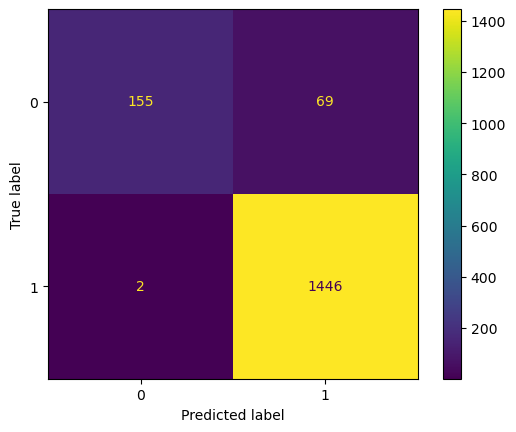

In [43]:


ConfusionMatrixDisplay.from_predictions(y_test, prediction_test_data)

plt.show()

In [44]:
def predict_email(message):
    
    input_data_features = feature_extraction.transform([message])

    prediction = model.predict(input_data_features)

    if prediction[0] == 0:
        return "Spam"
    else:
        return "Ham"

In [45]:
message = "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."
print(predict_email(message))

Ham


In [46]:
message ="URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18"
print(predict_email(message))

Spam


In [47]:
message ="I‘m going to try for 2 months ha ha only joking"
print(predict_email(message))

Ham


In [48]:
import pickle
filename = "spam_classifier_model.sav"

pickle.dump(model, open(filename, "wb"))

In [49]:
pickle.dump(feature_extraction, open("feature_extraction.pkl", "wb"))